In [1]:
import sys
from pathlib import Path

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))
import os
os.chdir(project_root)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data.pipeline import get_datasets
from src.models.transformer_model import StockTransformer
from src.utils.config import load_config, PROJECT_ROOT

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Build the test split for each variant using the real pipeline (same data/split as training).
def get_test_set(use_news: bool):
    cfg = load_config()
    cfg.data.use_news = use_news
    _, _, test_ds, feats = get_datasets(cfg)
    return test_ds, feats

test_base, feat_base = get_test_set(use_news=False)
test_news, feat_news = get_test_set(use_news=True)

news_only = [c for c in feat_news if c.startswith('news_')]
print(f'Base features: {len(feat_base)}')
print(f'News features: {len(feat_news)}  (+{len(news_only)} sentiment: {news_only})')
print(f'Test samples:  base={len(test_base)}, news={len(test_news)}')

Base features: 34
News features: 40  (+6 sentiment: ['news_compound', 'news_pos', 'news_neg', 'news_neu', 'news_count', 'news_has'])
Test samples:  base=1854, news=1854


In [3]:
def load_ckpt(name: str):
    """Load a trained StockTransformer, inferring its architecture from the weights."""
    cfg = load_config()
    path = PROJECT_ROOT / cfg.paths.models_dir / name
    ckpt = torch.load(path, map_location='cpu')
    sd = ckpt['model_state_dict']
    input_dim = sd['input_projection.weight'].shape[1]
    d_model = sd['input_projection.weight'].shape[0]
    n_layers = len([k for k in sd if 'encoder.layers' in k and 'self_attention.w_q.weight' in k])
    d_ff = sd['encoder.layers.0.feed_forward.linear1.weight'].shape[0]
    m = StockTransformer(
        input_dim=input_dim, d_model=d_model, n_heads=cfg.model.n_heads, n_layers=n_layers,
        d_ff=d_ff, dropout=cfg.model.dropout, activation=cfg.model.activation,
        prediction_horizon=cfg.data.prediction_horizon,
    )
    m.load_state_dict(sd)
    m.eval()
    return m, ckpt.get('score'), input_dim


model_base, vl_base, in_base = load_ckpt('best_model_base.pt')
model_news, vl_news, in_news = load_ckpt('best_model_news.pt')
print(f'base: val_loss={vl_base:.6f}, input_dim={in_base}')
print(f'news: val_loss={vl_news:.6f}, input_dim={in_news}')

base: val_loss=0.000110, input_dim=34
news: val_loss=0.000110, input_dim=40


In [4]:
def evaluate(model, test_ds, tag, val_loss):
    """Compute next-day return prediction metrics on the test split."""
    loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.append(model(x).cpu().numpy().reshape(-1))
            tgts.append(y.numpy().reshape(-1))
    preds = np.concatenate(preds)
    tgts = np.concatenate(tgts)
    return {
        'variant': tag,
        'val_loss': val_loss,
        'test_MAE': float(np.mean(np.abs(preds - tgts))),
        'test_RMSE': float(np.sqrt(np.mean((preds - tgts) ** 2))),
        'directional_acc': float(np.mean(np.sign(preds) == np.sign(tgts))),
        'pred_vs_actual_corr': float(np.corrcoef(preds, tgts)[0, 1]),
        'n_test': len(preds),
    }

In [5]:
res_base = evaluate(model_base, test_base, 'base', vl_base)
res_news = evaluate(model_news, test_news, 'news', vl_news)

summary = pd.DataFrame([res_base, res_news]).set_index('variant')
disp = summary.copy()
disp['directional_acc'] = (disp['directional_acc'] * 100).round(2).astype(str) + '%'
for c in ['val_loss', 'test_MAE', 'test_RMSE', 'pred_vs_actual_corr']:
    disp[c] = disp[c].round(6)
disp

,val_loss,test_MAE,test_RMSE,directional_acc,pred_vs_actual_corr,n_test
variant,,,,,,
base,0.00011,0.022624,0.033034,50.65%,0.053049,1854
news,0.00011,0.021327,0.032018,50.65%,0.008869,1854


In [6]:
delta = (res_news['directional_acc'] - res_base['directional_acc']) * 100
print(f"Directional accuracy: base={res_base['directional_acc']*100:.2f}%  "
      f"news={res_news['directional_acc']*100:.2f}%  (delta={delta:+.2f} pp)")
print(f"Pred-vs-actual corr : base={res_base['pred_vs_actual_corr']:.4f}  "
      f"news={res_news['pred_vs_actual_corr']:.4f}")
print(f"Validation loss     : base={vl_base:.6f}  news={vl_news:.6f}")
print(f"Test samples        : base={res_base['n_test']}, news={res_news['n_test']}")

Directional accuracy: base=50.65%  news=50.65%  (delta=+0.00 pp)
Pred-vs-actual corr : base=0.0530  news=0.0089
Validation loss     : base=0.000110  news=0.000110
Test samples        : base=1854, news=1854


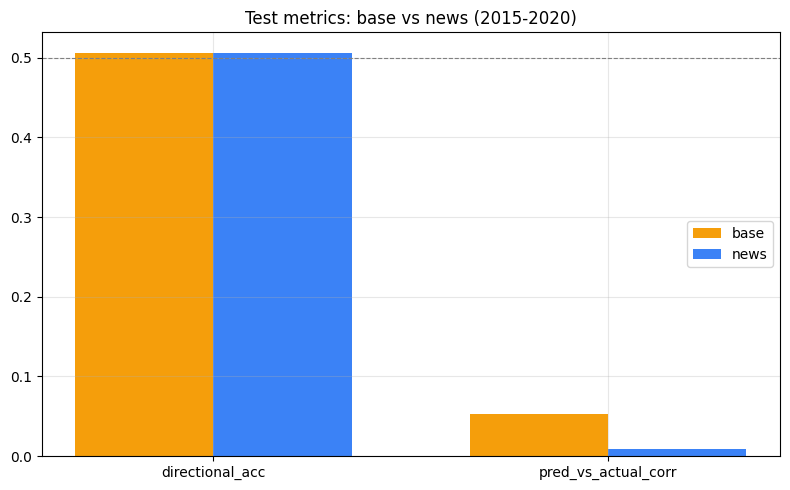

In [7]:
metrics = ['directional_acc', 'pred_vs_actual_corr']
x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, [res_base[m] for m in metrics], w, label='base', color='#f59e0b')
ax.bar(x + w / 2, [res_news[m] for m in metrics], w, label='news', color='#3b82f6')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Test metrics: base vs news (2015-2020)')
ax.legend()
plt.tight_layout()
plt.show()

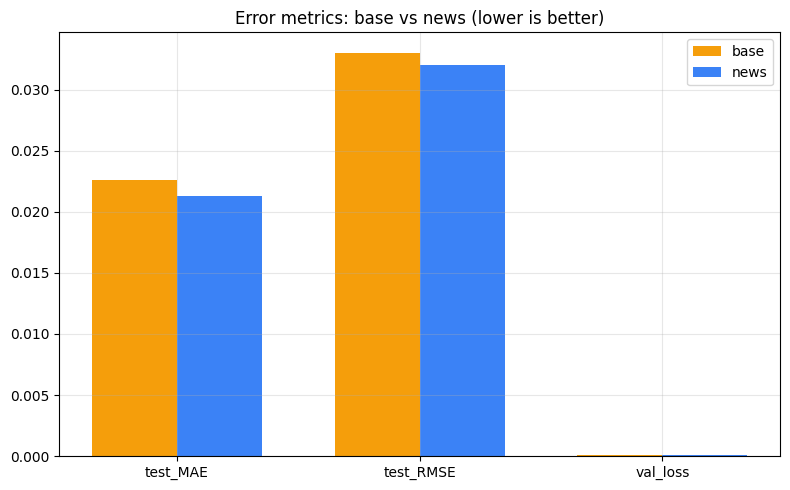

In [8]:
metrics2 = ['test_MAE', 'test_RMSE', 'val_loss']
x = np.arange(len(metrics2))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, [res_base[m] for m in metrics2], w, label='base', color='#f59e0b')
ax.bar(x + w / 2, [res_news[m] for m in metrics2], w, label='news', color='#3b82f6')
ax.set_xticks(x)
ax.set_xticklabels(metrics2)
ax.set_title('Error metrics: base vs news (lower is better)')
ax.legend()
plt.tight_layout()
plt.show()